# Pràctica de  Arbres de decisió i base de dades de "vendes de suc de taronja"

### Objectiu de la pràctica:

1. Aquest notebook il·lustra com utilitzar la tècnica dels arbres de decisió per determinar la marca que ha comprat el client en funció de les variables que descriuen la compra. **Suposarem que es tracta d'un problema que ens han encarregat resoldre i proporcionarem la següent explicació.**  
2. Fer servir l'EDA (Exploratory Data Analysis) per entendre la base de dades i el problema a resoldre.  
3. Aprendre a utilitzar els arbres de decisió.  
4. Aprendre a interpretar els arbres de decisió.  
5. Estudiar les dependències de la variable de compra ("purchase") en funció de les altres variables.  
6. Trobar regles senzilles que expliquin el comportament dels clients i les relacions entre les variables.


# 1. Descripció del problema   

## 1.1. Base de dades

La base de dades conté informació detallada sobre 1.070 compres de suc de taronja de les marques Citrus Hill i Minute Maid, realitzades per diferents clients en diverses botigues durant un període determinat. Per a cada compra, s'enregistra la marca escollida, la setmana de compra, la botiga específica, els preus originals i amb descompte de cada marca, així com la presència de promocions especials. A més, es quantifica la fidelitat dels clients a cada marca i es calcula la diferència de preu de venda entre les dues opcions. Aquesta informació permet analitzar factors com l'impacte dels preus, les promocions i la fidelitat dels clients en la decisió de compra dels consumidors.

## 1.2. Descripció de les variables de la base de dades de vendes de suc de taronja


| **Variable**       | **Descripció**                                                                                  |
|---------------------|-----------------------------------------------------------------------------------------------|
| **Purchase**        | Un factor que indica si el client va comprar suc de taronja de Citrus Hill (CH) o Minute Maid (MM). |
| **WeekofPurchase**  | La setmana de la compra.                                                                      |
| **StoreID**         | L'ID de la botiga on es va fer la compra.                                                     |
| **PriceCH**         | El preu cobrat pel suc de taronja de Citrus Hill.                                             |
| **PriceMM**         | El preu cobrat pel suc de taronja de Minute Maid.                                             |
| **DiscCH**          | El descompte ofert pel suc de taronja de Citrus Hill.                                         |
| **DiscMM**          | El descompte ofert pel suc de taronja de Minute Maid.                                         |
| **SpecialCH**       | Indicador de si hi havia una promoció especial pel suc de taronja de Citrus Hill.             |
| **SpecialMM**       | Indicador de si hi havia una promoció especial pel suc de taronja de Minute Maid.             |
| **LoyalCH**         | Fidelitat del client a la marca Citrus Hill.                                                  |
| **SalePriceMM**     | Preu de venda del suc de taronja de Minute Maid.                                              |
| **SalePriceCH**     | Preu de venda del suc de taronja de Citrus Hill.                                              |
| **PriceDiff**       | La diferència de preu de venda entre Minute Maid i Citrus Hill.                               |
| **Store7**          | Indicador de si la venda es va fer a la botiga 7.                                             |
| **PctDiscMM**       | Percentatge de descompte pel suc de taronja de Minute Maid.                                   |
| **PctDiscCH**       | Percentatge de descompte pel suc de taronja de Citrus Hill.                                   |
| **ListPriceDiff**   | La diferència de preu de llista entre Minute Maid i Citrus Hill.                              |
| **STORE**           | Identificador de quina de les cinc botigues es tracta.                                        |

### Bibliografia

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning: With Applications in Python*. Springer Nature.
- Stine, R. A., Foster, D. P., & Waterman, R. P. (1998). *Business Analysis Using Regression*.


## <font color="red"><b>Exercici 1</b></font>
1. Per tal de clarificar els objectius d'aquesta pràctica, redactar un paràgraf resumint el tipus de base de dades utilitzada i l'objectiu de la pràctica.
2. Abans d'aplicar mètodes d'Intel.ligència artificial, cal tenir una intuició sobre com influencien les variables observacionals  el resultat. A partir de la descripció de les variables escrigui breument la llista de variables que poden agumentar o disminuir la probabilitat de compra. Redactar  una explicació d'una línia per justificar cada cas.

Es tracta d'una base de dades que ens explica la venda de sucs de taronja de dues marques diferents d'on tenim variables.

# 2. Arbres de Decisió: Una Introducció Intuïtiva

## 2.1. Què són els arbres de decisió?

Els arbres de decisió són un mètode d'aprenentatge automàtic que **infereix regles a partir de dades**.
Es tracta d'un model predictiu que utilitza una estructura en forma d'arbre per prendre decisions a partir de diferents condicions. Cada **node** de l'arbre representa una pregunta sobre un atribut de les dades, i cada **branca** correspon a una resposta possible a aquesta pregunta. El procés continua fins que s'arriba a un **fulla** de l'arbre, on es pren una decisió final o es fa una predicció.

**Metàfora:**  Seqüències "if then else" que determinen regles per decidir.

### 2.1.1. Exemple Sencill: Regles per decidir si viatjar o romandre a casa

Imaginarem un arbre de decisió per decidir si val la pena **viatjar** o **romandre a casa** en funció de tres variables:

- **Ventós**: 0 (no ventós), 1 (ventós)
- **Temperatura**: 0 (baix), 1 (alt)
- **Clima**: 0 (dolent), 1 (bo)
- 
### Un exemple de la base de dades:

|   | Viatjar | Romandre a casa | Viatjar | Romandre a casa | Viatjar | Viatjar | Viatjar | Romandre a casa | Viatjar | Romandre a casa | Viatjar | Viatjar | Viatjar | Viatjar |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Clima | 0 | 1 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 1 | 1 | 1 | 0 |
| Temperatura | 1 | 0 | 1 | 0 | 1 | 0 | 0 | 1 | 1 | 0 | 1 | 1 | 0 | 0 |
| Ventós | 0 | 1 | 1 | 0 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 1 | 1 | 0 |


### 2.1.2. L'estructura  de l'arbre després del procés d'inferència:


<img src="ExempleArbre.png" width="60%">

* Una representació de les regles del arbre anterior:


| **Ventós** | **Temperatura** | **Clima** | **Decisió** |
|------------|-----------------|-----------|-------------|
| <= 0.50    | <= 0.50         | <= 0.50   | Viatjar     |
| <= 0.50    | <= 0.50         | > 0.50    | Viatjar     |
| <= 0.50    | > 0.50          | <= 0.50   | Romandre a casa |
| <= 0.50    | > 0.50          | > 0.50    | Romandre a casa |
| > 0.50     | <= 0.50         |           | Romandre a casa |
| > 0.50     | > 0.50          |           | Viatjar     |

### 2.1.3. Explicació: Interpretació de l'arbre de decisió


1. **Primer node (Ventós):**
   - Si `Ventós ≤ 0.50` (no fa vent), es passa a revisar la temperatura.
   - Si `Ventós > 0.50` (fa vent), es revisa el clima:
     - Si `Clima ≤ 0.50` (ennuvolat), la decisió és **Romandre a casa**.
     - Si `Clima > 0.50` (assolellat), la decisió és **Viatjar**.

2. **Segon node (Temperatura):**
   - Si `Temperatura ≤ 0.50` (no fa calor), es revisa el clima:
     - Si `Clima ≤ 0.50` (ennuvolat), la decisió és **Viatjar**.
     - Si `Clima > 0.50` (assolellat), la decisió és també **Viatjar**.
   - Si `Temperatura > 0.50` (fa calor), independentment del clima, la decisió és **Romandre a casa**.
     
Aquest arbre és un exemple senzill de com els arbres de decisió poden utilitzar dades categòriques o numèriques per predir una classe. Cada camí des de l'arrel fins a una fulla representa una seqüència de decisions que porten a una predicció. Aquesta estructura fa que els arbres de decisió siguin intuïtius i fàcils d'interpretar.

### Bibliografia

- Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). *Classification and Regression Trees*. Chapman and Hall/CRC.
- Duda, R. O., Hart, P. E., & Stork, D. G. (2001). *Pattern Classification* (2nd ed.). John Wiley & Sons.

## <font color="red"><b>Exercici 2</b></font>
1. Per tal de clarificar el concepte, redactar un paràgraf explicant que és un arbre de decisió.

Un arbre de decissió representa una sequencia de decisions segons unes variables amb les quals decidim algun resultat. En l'exemple ho veiem amb tres variables meteorlogiques per veure si es recomanable viatjar.


# 3. Part pràctica.

* ###  Primer carreguem les llibreries de python 
* ###  Desprès carreguem la base de dades


#### 3.1.1  Carreguem les llibreries que farem servir.

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt


#### 3.1.2 Carreguem la base de dades de un fitxer tipus 'comma separated values' a un DataFrame de Pandas.

In [26]:
df_DataBase = pd.read_csv('OJ.csv')
df_DataBase.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


#### 3.1.3. Transformació de les variables qualitatives a numèriques

In [27]:
df_DataBase['Store7'] = df_DataBase['Store7'].map({'Yes': 1, 'No': 0})
df_DataBase['Purchase'] = df_DataBase['Purchase'].map({'CH': 1, 'MM': 0})
df_DataBase.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,1,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,0,0.000000,0.000000,0.24,1
1,1,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,0,0.150754,0.000000,0.24,1
2,1,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,0,0.000000,0.091398,0.23,1
3,0,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,0,0.000000,0.000000,0.00,1
4,1,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,1,0.000000,0.000000,0.00,0


## 3.2. Tipus de dades de la base de dades, correcció a float.

In [28]:
df_DataBase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Purchase        1070 non-null   int64  
 1   WeekofPurchase  1070 non-null   int64  
 2   StoreID         1070 non-null   int64  
 3   PriceCH         1070 non-null   float64
 4   PriceMM         1070 non-null   float64
 5   DiscCH          1070 non-null   float64
 6   DiscMM          1070 non-null   float64
 7   SpecialCH       1070 non-null   int64  
 8   SpecialMM       1070 non-null   int64  
 9   LoyalCH         1070 non-null   float64
 10  SalePriceMM     1070 non-null   float64
 11  SalePriceCH     1070 non-null   float64
 12  PriceDiff       1070 non-null   float64
 13  Store7          1070 non-null   int64  
 14  PctDiscMM       1070 non-null   float64
 15  PctDiscCH       1070 non-null   float64
 16  ListPriceDiff   1070 non-null   float64
 17  STORE           1070 non-null   i

#### Correcció dels tipus de dades.

In [29]:
df_DataBase = df_DataBase.astype(float)
df_DataBase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Purchase        1070 non-null   float64
 1   WeekofPurchase  1070 non-null   float64
 2   StoreID         1070 non-null   float64
 3   PriceCH         1070 non-null   float64
 4   PriceMM         1070 non-null   float64
 5   DiscCH          1070 non-null   float64
 6   DiscMM          1070 non-null   float64
 7   SpecialCH       1070 non-null   float64
 8   SpecialMM       1070 non-null   float64
 9   LoyalCH         1070 non-null   float64
 10  SalePriceMM     1070 non-null   float64
 11  SalePriceCH     1070 non-null   float64
 12  PriceDiff       1070 non-null   float64
 13  Store7          1070 non-null   float64
 14  PctDiscMM       1070 non-null   float64
 15  PctDiscCH       1070 non-null   float64
 16  ListPriceDiff   1070 non-null   float64
 17  STORE           1070 non-null   f

## <font color="red"><b>Exercici 3</b></font>
1. Expliqui en una linea que fa el métode .astype(float) sobre el DataFrame.

Convertim totes les variables a tipus float. 

## 3.3. Anàlisi exploratòria de dades (EDA)
L'anàlisi exploratòria de dades (EDA) permet entendre les característiques  d'una  base de dades. A través de visualitzacions i estadístiques descriptives, s'identifiquen patrons, anomalies i relacions entre les variables.

### 3.3.1 Estadistics descriptius.

In [30]:
df_DataBase.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Purchase,1070.0,0.61,0.49,0.00,0.00,1.00,1.00,1.00
WeekofPurchase,1070.0,254.38,15.56,227.00,240.00,257.00,268.00,278.00
StoreID,1070.0,3.96,2.31,1.00,2.00,3.00,7.00,7.00
PriceCH,1070.0,1.87,0.10,1.69,1.79,1.86,1.99,2.09
PriceMM,1070.0,2.09,0.13,1.69,1.99,2.09,2.18,2.29
DiscCH,1070.0,0.05,0.12,0.00,0.00,0.00,0.00,0.50
DiscMM,1070.0,0.12,0.21,0.00,0.00,0.00,0.23,0.80
SpecialCH,1070.0,0.15,0.35,0.00,0.00,0.00,0.00,1.00
SpecialMM,1070.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
LoyalCH,1070.0,0.57,0.31,0.00,0.33,0.60,0.85,1.00


## <font color="red"><b>Exercici 4</b></font>
1. Detecti si hi han variables on la el percentil 50% sigui diferent de la mitjana, i la desviació estandard molt diferent del interval interquantil (25%-75%).

Purchase, StoreID, Store7, STORE

## 3.1.1 Diagrama en capces (Box Plot).

In [31]:
df_DataBase['Purchase']

0       1.0
1       1.0
2       1.0
3       0.0
4       1.0
       ... 
1065    1.0
1066    1.0
1067    0.0
1068    1.0
1069    1.0
Name: Purchase, Length: 1070, dtype: float64

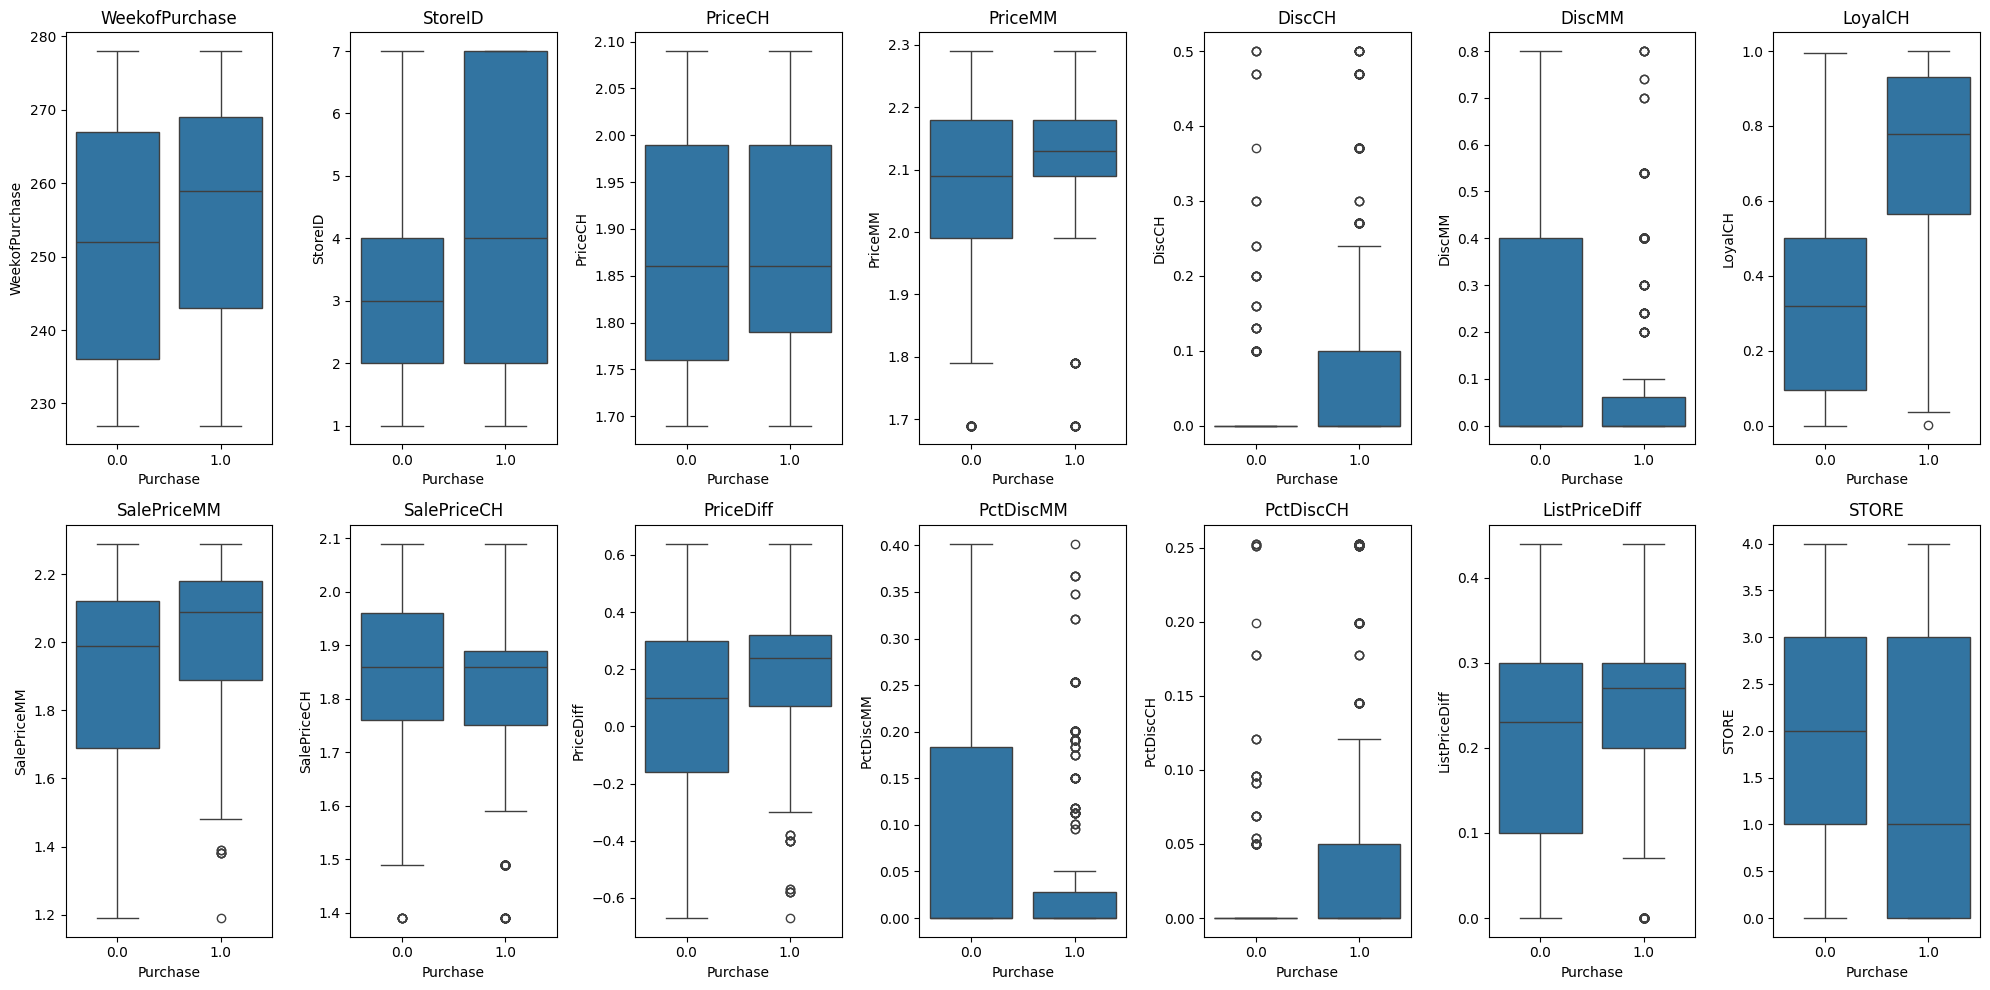

In [32]:

# Definir les variables a representar (excloent les variables binàries)
variables = df_DataBase.columns
non_binary_vars = [var for var in variables if df_DataBase[var].nunique() > 2]

# Crear una figura amb 2 files i 7 columnes
fig, axes = plt.subplots(2, 7, figsize=(20, 10))

# Aplanar l'array d'eixos per facilitar la iteració
axes = axes.flatten()

# Representar cada variable no binària
for i, var in enumerate(non_binary_vars):
    sns.boxplot(y=df_DataBase[var], x =df_DataBase['Purchase'] , ax=axes[i])
    axes[i].set_title(var)


# Ajustar 
plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 5</b></font>

   Una de les avantatges dels arbres de decisió és que poden treballar amb dades no gausianes, amb valors extrems (outliers) i amb unitats diferentes (kg,gm, anys, segons, etc), pel fet que compara valors. 
1. En un paràgraf, expliqui de forma general la distribució de les variables: asimetria, marges dinàmics molt diferents, presència de outliers, etc.

StoreID: Quan la compra és 1, la variació és molt més gran amb el percentil 50 a 4 mentre que quan la compra és 0, hi ha una variànça més petita amb el percentil 50 a 3 i sense tenir valors per sobre de 4. 

DiscCH: Si la compra és de tipus 0, pràcticament sempre és 0, però en canvi tenim alguns outliers que arriben fins a 0.5. En canvi, quan la compra és de tipus 1, El percentil 50 està a 0,1 i també tenim alguns outliers fins a 0.5. Com a regla general però veiem que la marca 0més quan està d'oferta.

ListPriceDiff: Veiem que en el cas de compra 0, el percentil està a 0.23 però al cas 1 està a 0.26, tot i aixó, la principal diferència és que el cas 0, té una major variància, amb més valors entre 0.1 i 0 mentre que l'altre cas té una variància més petita i uns pocs outliner a 0.



2. Detecti si hi han variables que siguin molt predictives de compra (Purchase)

En les que hi ha més diferència entre el gràfic de l'esquerra i el de la dreta, és a dir DiscCH, DiscMM, LoyalCH, PctDiscMM

3. Per aprendre Python.  
   2.1 Expliqui breument què fa la instrucció: [var for var in variables if df_DataBase[var].nunique() > 2]

Crea una llista amb els noms de totes les variables.

   2.2 Expliqui breument què fa la instrucció: enumerate(non_binary_vars)

Retorna una llista amb les variables a recorrer.

* Recordatori de les variables:
* 
 | <font size="1">**Variable**</font> | <font size="1">**Descripció**</font> |
|---------------------|-----------------------------------------------------------------------------------------------|
| <font size="1">**Purchase**</font> | <font size="1">Un factor que indica si el client va comprar suc de taronja de Citrus Hill (CH) o Minute Maid (MM).</font> |
| <font size="1">**WeekofPurchase**</font> | <font size="1">La setmana de la compra.</font> |
| <font size="1">**StoreID**</font> | <font size="1">L'ID de la botiga on es va fer la compra.</font> |
| <font size="1">**PriceCH**</font> | <font size="1">El preu cobrat pel suc de taronja de Citrus Hill.</font> |
| <font size="1">**PriceMM**</font> | <font size="1">El preu cobrat pel suc de taronja de Minute Maid.</font> |
| <font size="1">**DiscCH**</font> | <font size="1">El descompte ofert pel suc de taronja de Citrus Hill.</font> |
| <font size="1">**DiscMM**</font> | <font size="1">El descompte ofert pel suc de taronja de Minute Maid.</font> |
| <font size="1">**SpecialCH**</font> | <font size="1">Indicador de si hi havia una promoció especial pel suc de taronja de Citrus Hill.</font> |
| <font size="1">**SpecialMM**</font> | <font size="1">Indicador de si hi havia una promoció especial pel suc de taronja de Minute Maid.</font> |
| <font size="1">**LoyalCH**</font> | <font size="1">Fidelitat del client a la marca Citrus Hill.</font> |
| <font size="1">**SalePriceMM**</font> | <font size="1">Preu de venda del suc de taronja de Minute Maid.</font> |
| <font size="1">**SalePriceCH**</font> | <font size="1">Preu de venda del suc de taronja de Citrus Hill.</font> |
| <font size="1">**PriceDiff**</font> | <font size="1">La diferència de preu de venda entre Minute Maid i Citrus Hill.</font> |
| <font size="1">**Store7**</font> | <font size="1">Indicador de si la venda es va fer a la botiga 7.</font> |
| <font size="1">**PctDiscMM**</font> | <font size="1">Percentatge de descompte pel suc de taronja de Minute Maid.</font> |
| <font size="1">**PctDiscCH**</font> | <font size="1">Percentatge de descompte pel suc de taronja de Citrus Hill.</font> |
| <font size="1">**ListPriceDiff**</font> | <font size="1">La diferència de preu de llista entre Minute Maid i Citrus Hill.</font> |
| <font size="1">**STORE**</font> | <font size="1">Identificador de quina de les cinc botigues es tracta.</font> | 

#### Probabilitat de compra.

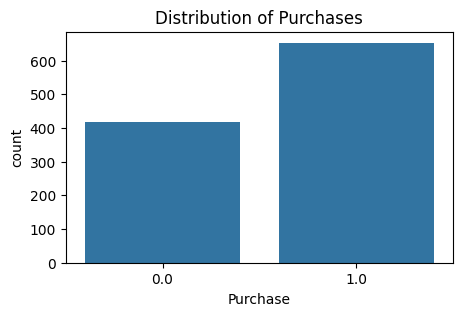

Valor promig de probabilitat de compra: 61.03 %


In [33]:
plt.figure(figsize=(5, 3)) 
sns.countplot(x='Purchase', data=df_DataBase)
plt.title('Distribution of Purchases')
plt.show()
print(f'Valor promig de probabilitat de compra: {df_DataBase.Purchase.mean()*100:2.2f} %')

## <font color="red"><b>Exercici 6</b></font>
1. Escrigui en una línea el codi d'un programa clasificador de compra amb un encert del 61%.

Purchase = 1;

#### Comparació d'histogrames de variables seleccionades factorizant per compra

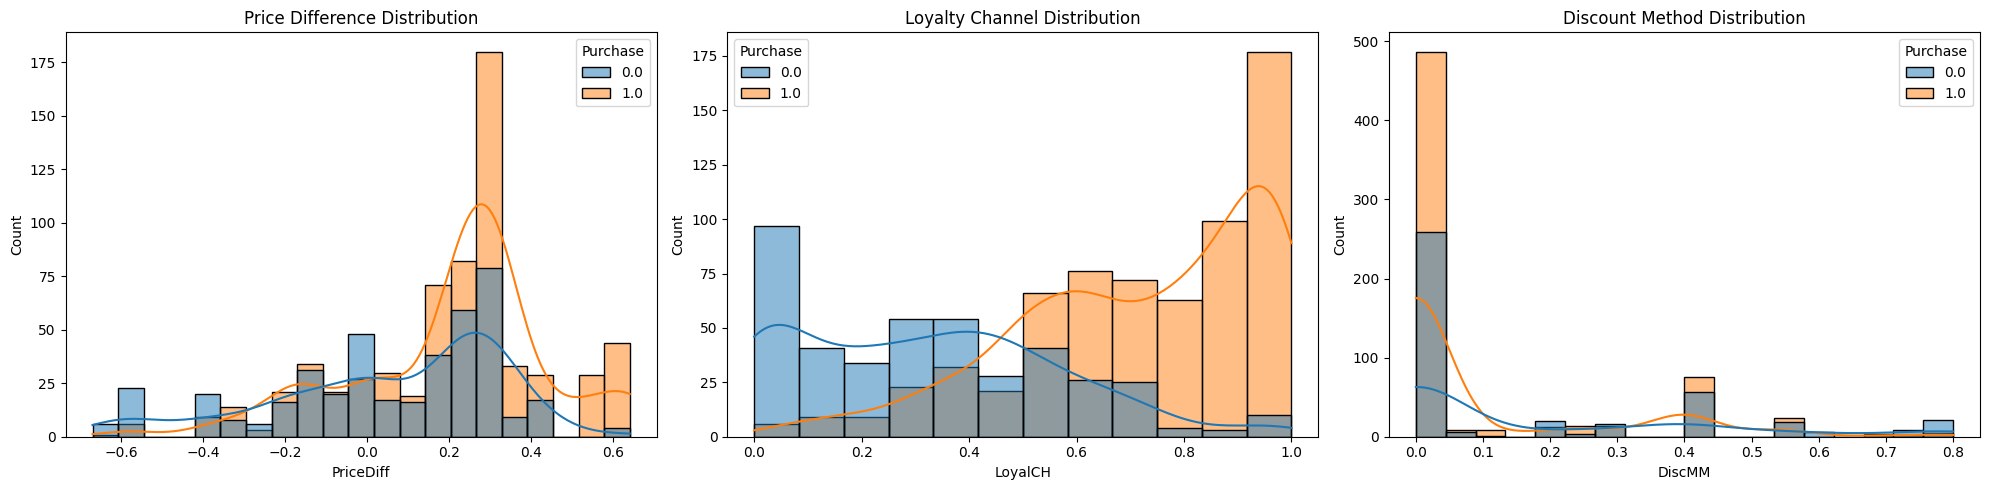

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot for 'PriceDiff'
sns.histplot(data=df_DataBase, x='PriceDiff', hue='Purchase', kde=True, ax=axes[0])
axes[0].set_title('Price Difference Distribution')

# Plot for 'LoyalCH'
sns.histplot(data=df_DataBase, x='LoyalCH', hue='Purchase', kde=True, ax=axes[1])
axes[1].set_title('Loyalty Channel Distribution')

# Plot for 'DiscMM'
sns.histplot(data=df_DataBase, x='DiscMM', hue='Purchase', kde=True, ax=axes[2])
axes[2].set_title('Discount Method Distribution')

plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 7</b></font>
1. Analitzi els histogrames anteriors, i per cada variable indiqui els marges en que la venda es mes posible i en una liniea dóni una explicació.

PriceDiff: Tot i estar els dos gràfics una mica encabalcats, fins a priceDiff = 0.1, hi ha una tendència de les compres 0, mentre que per sobre, de les compres 1.

Si LoyalCH < 0.5, compra tipus 0.

DiscMM: ambdós gràfics estan encabalcats.



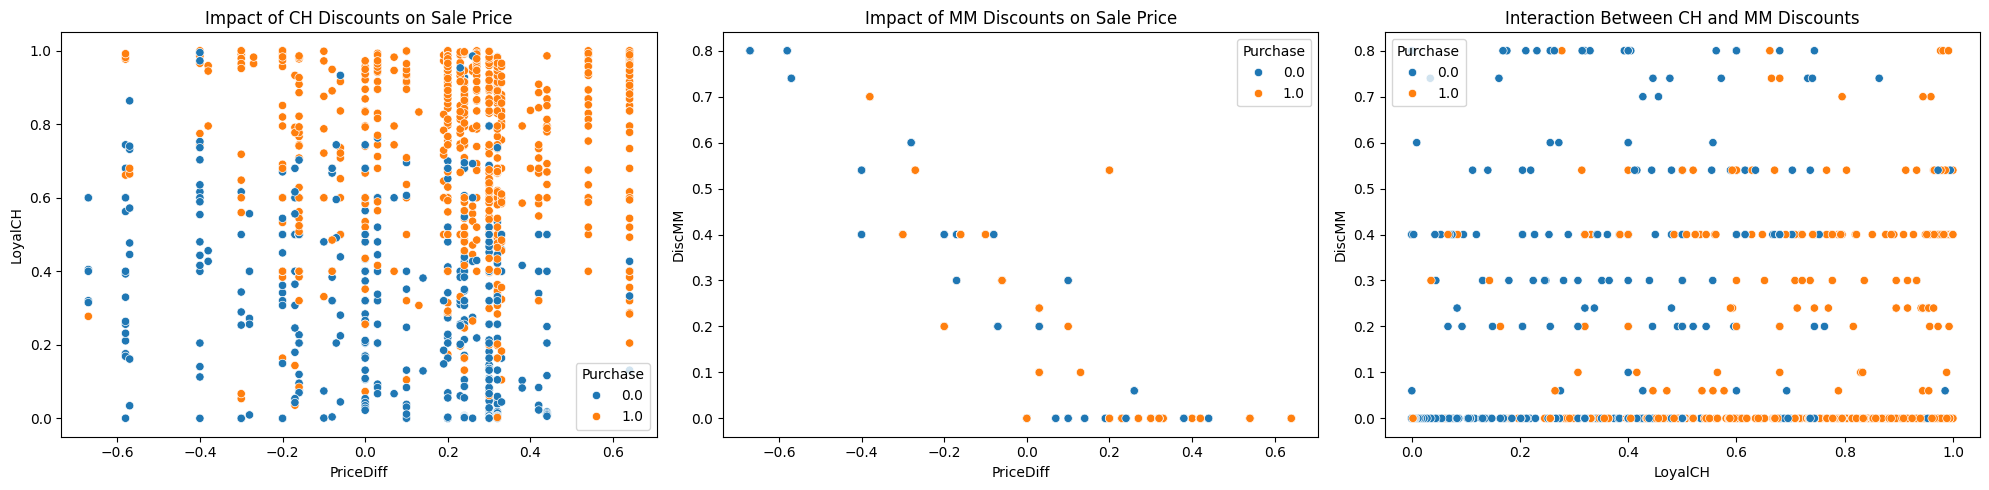

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Scatter plot for PriceDiff vs LoyalCH
sns.scatterplot(x='PriceDiff', y='LoyalCH', hue='Purchase', data=df_DataBase, ax=axes[0])
axes[0].set_title('Impact of CH Discounts on Sale Price')

# Scatter plot for PriceDiff vs DiscMM
sns.scatterplot(x='PriceDiff', y='DiscMM', hue='Purchase', data=df_DataBase, ax=axes[1])
axes[1].set_title('Impact of MM Discounts on Sale Price')

# Scatter plot for LoyalCH vs DiscMM
sns.scatterplot(x='LoyalCH', y='DiscMM', hue='Purchase', data=df_DataBase, ax=axes[2])
axes[2].set_title('Interaction Between CH and MM Discounts')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## <font color="red"><b>Exercici 8</b></font>
1.  Analitzi els diagrames de dispersions anteriors, i per cada combinació de variables indiqui si hi ha una dependència en les combinacions i la probabilitat de venda  i en una liniea dóni una explicació.

Al primer gràfic, veiem que fins a priceDiff = 0, hi ha una tendència major del cas 0 i per sobre de 0, hi ha una tendència de compres a partir de LoyalCH = 0.6. 

Veiem que hi ha una correlació negativa entre DiscMM, PriceDiff. 

Veiem que a partir de LoyalCH = 0.22 hi ha una tendència major del cas 1.

#### Distribució de preus per Citrus Hill i Minute Maid
Recordar la codificació: df_DataBase['Purchase'].map({'CH': 1, 'MM': 0})
* Analisi de la sensibilitat al preu.

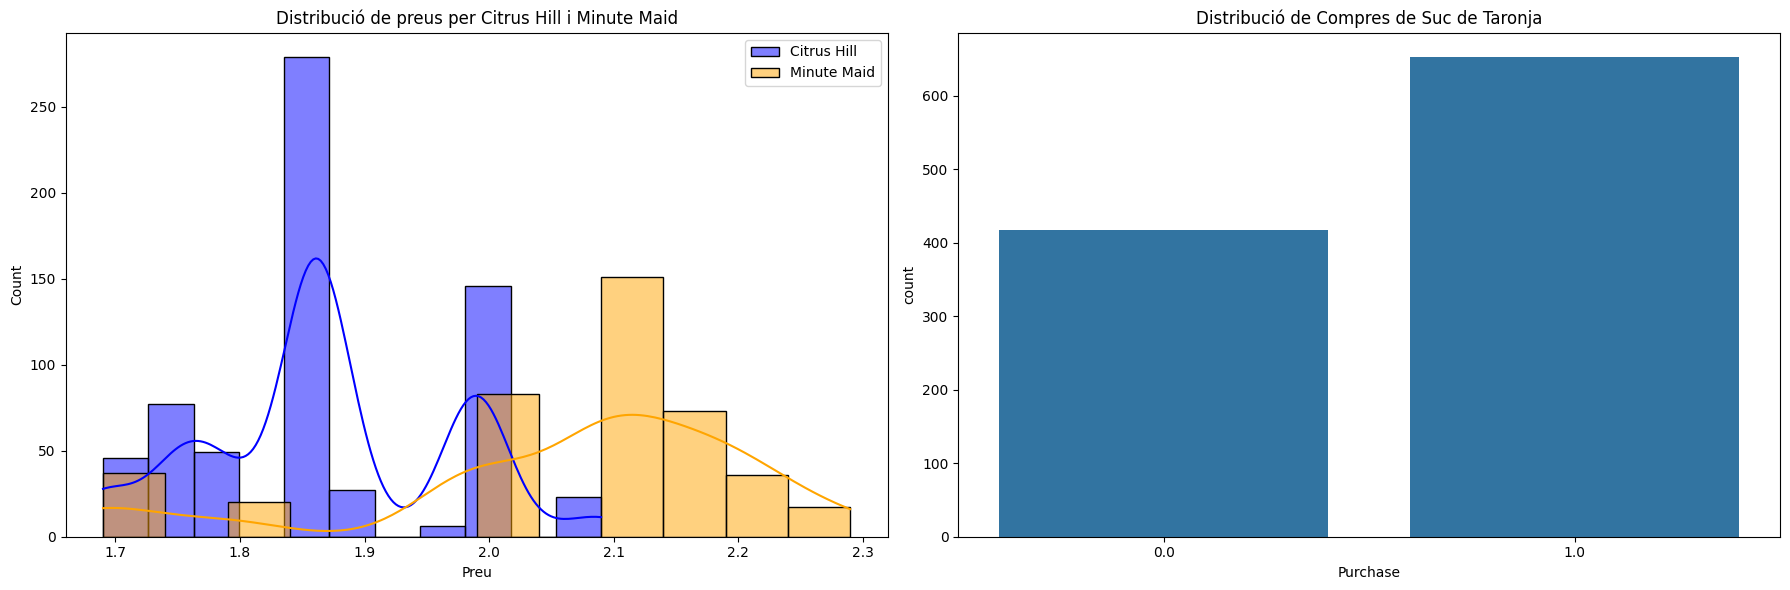

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))  # Create a figure with 1 row and 2 columns

# KDE plot for Citrus Hill and Minute Maid prices
sns.histplot(ax=ax1, data=df_DataBase[df_DataBase['Purchase'] == 1.]['PriceCH'], kde=True, color='blue', label='Citrus Hill')
sns.histplot(ax=ax1, data=df_DataBase[df_DataBase['Purchase'] == 0.]['PriceMM'], kde=True, color='orange', label='Minute Maid')
ax1.set_title('Distribució de preus per Citrus Hill i Minute Maid')
ax1.set_xlabel('Preu')
ax1.legend()

# Countplot for purchase distribution
sns.countplot(ax=ax2, x='Purchase', data=df_DataBase)
ax2.set_title('Distribució de Compres de Suc de Taronja')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

## <font color="red"><b>Exercici 9</b></font>
1. En base a l'histograma anterior, expliqui en una línia quina marca té més possibilitats de vendre's.
2. Quina utilitat pot tenir la instrucció: kde=True

TENINT EN COMPTE QUE CITRUS HILL ÉS LA COMPRA 1, veiem del gràfic de l'esquerra que es venen més sucs d'aquesta marca, també ho podem veure perquè l'histograma de l'esquerra també pren valors més grans. 
L'instrucció kde=True, ens serveix per tenir les gràfiques més suaus i suposant aquesta variació, interpolar per estimar els valors per x que no tenim com per exemple preu=1.5

#### La KDE, o "Kernel Density Estimation".
* La KDE és una tècnica estadística que ens ajuda a visualitzar la distribució de dades contínues de manera suau i contínua. En lloc d'utilitzar un histograma, que crea barres per representar la freqüència de dades dins d'intervals específics, la KDE crea una corba suau que estima la densitat de probabilitat en diferents punts al llarg de l'interval de dades.

#### Eficàcia dels Descomptes
Com afecten els descomptes a les vendes de cada marca. Aquests gràfics mostren com els descomptes afecten el preu de venda final per a cada marca. 

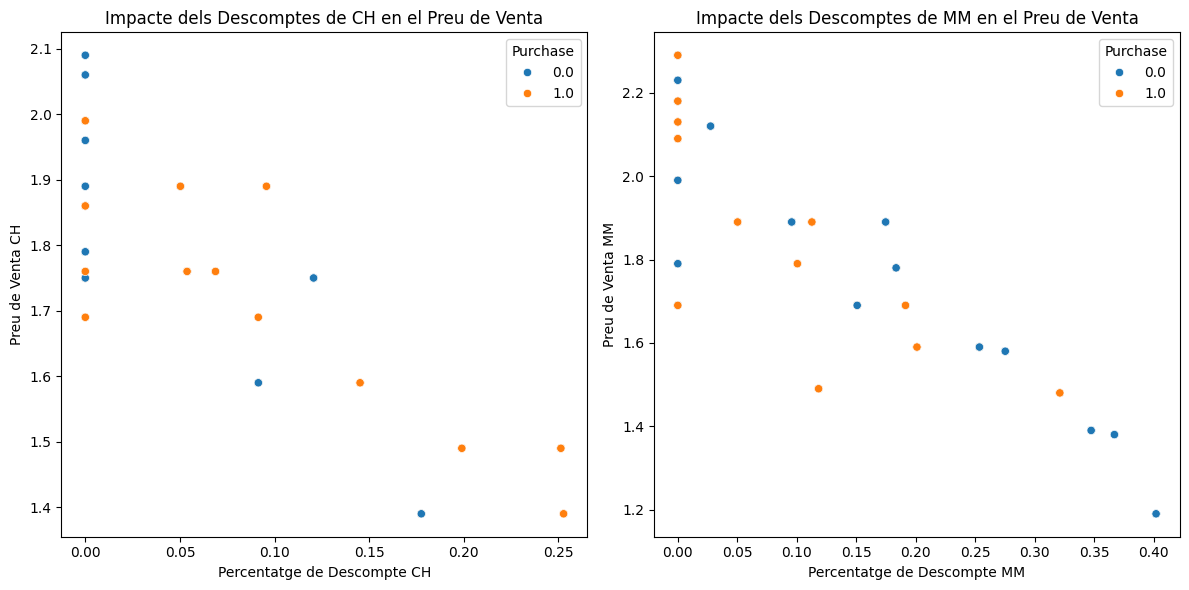

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear una figura amb dos subgràfics en una fila
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6)) 

# Primer gràfic de dispersió: Impacte dels descomptes de CH
sns.scatterplot(ax=ax1, x='PctDiscCH', y='SalePriceCH', hue='Purchase', data=df_DataBase)
ax1.set_title('Impacte dels Descomptes de CH en el Preu de Venta') 
ax1.set_xlabel('Percentatge de Descompte CH')
ax1.set_ylabel('Preu de Venta CH')

# Segon gràfic de dispersió: Impacte dels descomptes de MM
sns.scatterplot(ax=ax2, x='PctDiscMM', y='SalePriceMM', hue='Purchase', data=df_DataBase)
ax2.set_title('Impacte dels Descomptes de MM en el Preu de Venta')
ax2.set_xlabel('Percentatge de Descompte MM')
ax2.set_ylabel('Preu de Venta MM')

plt.tight_layout() 
plt.show()

## <font color="red"><b>Exercici 10</b></font>
1. En base al diagrama de dispersió anterior, expliqui en dos linies  si els descomptes són efectius per augmentar les vendes en cada marca.

Observem que a major descompte la mateixa marca presenta una mica més de ventes, encara que tenim poques observacions. Ho podem notar en el primer gràfic on amb més descompte veiem méspunts taronjes (CITRUS HILL). En el segon gràfic, observem el mateix amb els punts blaus (MINUTE MAID) dels quals obtenim més amb major descompte. 

# 4.0 Resultats amb  arbres de decisió.
## 4.1 Per què un arbre de decisió és una bona solució

Raons:

1. **Interpretabilitat**:  L'estructura de l'arbre permet visualitzar el procés de presa de decisions a cada nivell, fent clar com el model arriba a les seves prediccions.

2. **Gestió de Diferents Tipus de Dades**: Els arbres de decisió poden tractar tant dades numèriques com categòriques sense necessitat de preprocessament:

   1. estandarització.
   2. Convertir variables categòriques en numériques. 
3. **Robustesa a l'Escala**: Els arbres de decisió no són sensibles a l'escala de les variables, al fer comparacions, no depen de l'escala/unitats de les variables.
   1. La comparació $Pes > 1$kg, es tracta igual que $Pes > 1000$ grms.
   2. A diferència d'alguns altres algorismes, com la regressió lineal, els arbres de decisió no requereixen  normalització o estandardització.

4. **Relacions No Lineals**: Els arbres de decisió poden capturar relacions no lineals entre les característiques i la variable objectiu. Això és útil per a conjunts de dades complexos on la relació entre variables no és estrictament lineal.

### Comparació amb Regressió i K-means

- **Regressió**:
  - **Regressió Lineal**: Assumeix una relació lineal entre les característiques i la variable objectiu. Requereix escalatge de característiques i pot no funcionar bé si la relació és no lineal.
  - **Arbre de Decisió**: Pot capturar relacions no lineals i no requereix escalatge de característiques. És més flexible en la gestió de conjunts de dades complexos.

- **K-means Clustering**:
  - **K-means**: Un algorisme de clustering utilitzat per a l'aprenentatge no supervisat. Agrupa punts de dades en clústers basats en la seva similitud. És sensible a l'escalatge de variables i requereix escalatge de característiques.
  - **Arbre de Decisió**: Un algorisme d'aprenentatge supervisat utilitzat per a tasques de classificació i regressió. Prediu directament la variable objectiu i és robust a l'escalatge de variables.




## <font color="red"><b>Exercici 11</b></font>
1. Per aclarir idees, resumeixi en un paràgraf els avantatges dels arbres de decisió enfront d'altres mètodes.

Els arbres de decisió ens permeten tractar amb variables numèriques sense la necessitat de preprocessar-les, poden estar amb valors diferents (sense tenir en compte si una variable pren valors de 0-0.1 i l'altra de 0-3500). En comparació amb la regressió lineal, podem operar amb més flexibilitat en cas de conjunts de dades complexos. Si ho comparem amb l'algoritme k-means, és més robust a l'escalatge de característiques.


## 4.2 Partició de la base en train i test

In [38]:
features = ['WeekofPurchase', 'StoreID', 'PriceCH', 'PriceMM', 'DiscCH', 'DiscMM', 'SpecialCH', 'SpecialMM', 'LoyalCH', 'SalePriceMM', 'SalePriceCH', 'PriceDiff', 'Store7', 'PctDiscMM', 'PctDiscCH', 'ListPriceDiff', 'STORE']
target = 'Purchase'

X_train, X_test, y_train, y_test = train_test_split(df_DataBase[features], df_DataBase[target], test_size=0.25, random_state=42)



## <font color="red"><b>Exercici 13</b></font>
1. En dos linies, expliqui perqué es fa la partició en train i test.

Fem la partició de les dades en train i test degut a la necessitat de que les dades amb las que aprén el model siguin diferents amb las que el testejem. De aquesta forma podem evitar que el model aprengui caracteristiques presents a les dades que provinguin del soroll, asegurant un millor resultat.

2. **Quina propietat** tenen els arbres que fa que no sigui necesari fer una estandarització de les dades?

Les comparacions es fan de forma que cada pregunta es fa independent de les altres de manera que les comparacions són entre les mateixes propies variables, i per tant no fa falta estandaritzar-les perquè decidim en base a preguntes entre la mateixa variable.

## 4.3 Estimació del arbre.

*  Inicialitzar i entrenar el classificador d'arbre de decisió

In [39]:

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## 4.3. Recordatori: Avaluació del Model

## Paràmetres d'Avaluació de la qualitat del model

### 1. Precisió (Precision)
**Definició:** La precisió és la relació entre les instàncies predites correctament i el total d'instàncies en el conjunt de dades. Mesura l'efectivitat general del model.

$$\text{Precisió} = \frac{\text{VP} + \text{VN}}{\text{VP} + \text{VN} + \text{FP} + \text{FN}}$$

On:
- VP = Veritables Positius
- VN = Veritables Negatius
- FP = Falsos Positius
- FN = Falsos Negatius

### 2. Sensibilitat (Recall)
**Definició:** La sensibilitat, també coneguda com a recall, és la relació entre les observacions positives predites correctament i tots els positius reals. Mesura la capacitat del model per identificar instàncies positives.

$$\text{Sensibilitat} = \frac{\text{VP}}{\text{VP} + \text{FN}}$$

On:
- VP = Veritables Positius
- FN = Falsos Negatius

### 3. Puntuació F1 (F1-Score)
**Definició:** La puntuació F1 és la mitjana harmònica de l'exactitud i la sensibilitat. Proporciona un equilibri entre les dues mètriques, especialment en conjunts de dades desequilibrats.

$$\text{Puntuació F1} = 2 \times \frac{\text{Exactitud} \times \text{Sensibilitat}}{\text{Exactitud} + \text{Sensibilitat}}$$

### 4. Suport (Support):

**Definició:** El suport és el nombre d'ocurrències de cada classe en el conjunt de dades de test. Reflecteix la quantitat de dades disponibles per a cada classe per avaluar el rendiment del model.
$$Suport = TP + FN$$

On:
- **TP**: Nombre d'instàncies que són de la classe i han estat correctament predites com a tals.
- **FN**: Nombre d'instàncies de la classe que han estat incorrectament predites com a no pertanyents a la classe.


## 4.4 Predicció sobre la base de test i prestacions.

In [40]:
y_pred = clf.predict(X_test)

# Avaluar el model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Optionally, if you want to reset the index to make 'precision', 'recall', etc., as columns:
df_report = df_report.reset_index()
df_report = df_report.rename(columns={'index': 'class'})
print(f'Precisió: {accuracy*100:2.2f} %')
print('\n \n Informe de Classificació:')
df_report.set_index('class', inplace = True)

df_report.iloc[:2].round(2)

Precisió: 71.64 %

 
 Informe de Classificació:


,precision,recall,f1-score,support
class,,,,
0.0,0.66,0.63,0.64,109.0
1.0,0.75,0.77,0.76,159.0


## <font color="red"><b>Exercici 14</b></font>
1. En base a les definicions anteriors donar una explicació en un paràgraf del informe de classificació. Valori les prestacions del classificador.

La precisió ens dona una probabilitat de les vegades que encertem, en el nostre cas del 71.64, i acerta més el cas 0. 

El recall ens dona l'informació de les vegades que encerta els casos positius en comparació a les vegades que realment és positiu. Amb la marca 0 obtenim uns resultats no massa bons però en canvi amb la 1, obtenim un recall de 0.77. 

El F1-score ens dona un valor que té en compte recall i precission i observem el que haviem vist abans. 

Amb support veiem el número de mostres positives que teniem en tots dos casos, i veiem que la marca 1 ha estat més testejada que la 0.

### Recordatori: Matriu de confusió

**Definició:** Una matriu de confusió és una taula que s'utilitza per avaluar el rendiment d'un model de classificació. Resumeix el recompte de prediccions de veritables positius, veritables negatius, falsos positius i falsos negatius.

$$\begin{array}{|c|c|c|} \hline  & \text{Predicció Positiva} & \text{Predicció Negativa} \\ \hline \text{Real Positiu} & \text{VP} & \text{FN} \\ \hline \text{Real Negatiu} & \text{FP} & \text{VN} \\ \hline \end{array}$$

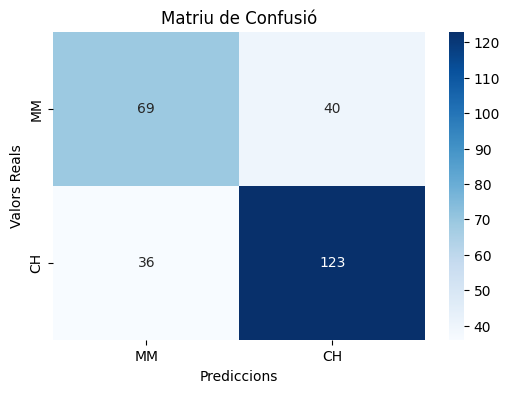

In [41]:
# Matriu de confusió
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['MM', 'CH'], yticklabels=['MM', 'CH'])
plt.xlabel('Prediccions')
plt.ylabel('Valors Reals')
plt.title('Matriu de Confusió')
plt.show()

## <font color="red"><b>Exercici 15</b></font>
1. En base a les definicions anteriors donar una explicació en un paràgraf de la Matriu de Confusió. Valori les prestacions del classificador.


Observem que acertem molt en els casos de CH = 1, però en canvi per MM acertem 69 cops i  fallem 36



## 4.5 Representació del arbre de decisió.

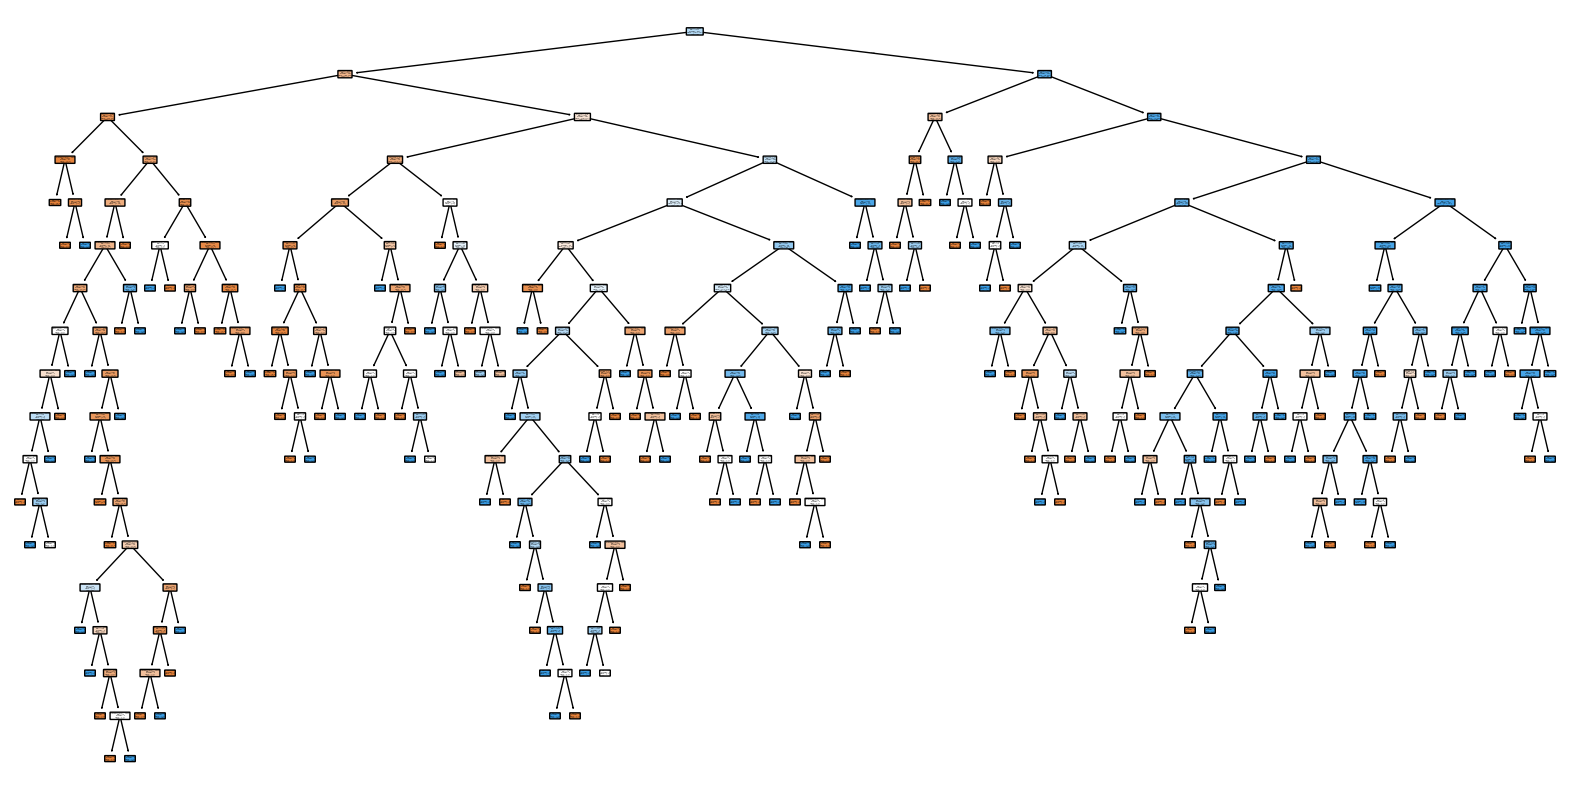

In [42]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, rounded=True, feature_names=features,  class_names=['CH', 'MM'])
plt.show()


In [43]:
from sklearn.tree import export_text

tree_rules = export_text(clf, feature_names=features)
print(tree_rules)

|--- LoyalCH <= 0.50
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.06
|   |   |   |--- WeekofPurchase <= 268.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- WeekofPurchase >  268.50
|   |   |   |   |--- PriceDiff <= 0.29
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- PriceDiff >  0.29
|   |   |   |   |   |--- class: 1.0
|   |   |--- LoyalCH >  0.06
|   |   |   |--- LoyalCH <= 0.21
|   |   |   |   |--- WeekofPurchase <= 273.00
|   |   |   |   |   |--- WeekofPurchase <= 261.00
|   |   |   |   |   |   |--- PriceDiff <= -0.13
|   |   |   |   |   |   |   |--- SalePriceMM <= 1.64
|   |   |   |   |   |   |   |   |--- WeekofPurchase <= 236.50
|   |   |   |   |   |   |   |   |   |--- WeekofPurchase <= 234.00
|   |   |   |   |   |   |   |   |   |   |--- LoyalCH <= 0.16
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |   |   |--- LoyalCH >  0.16
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |

## <font color="red"><b>Exercici 16</b></font>
1. Faci un crítica al arbre estimat?
 
   **Pista:** Recordar Overfitting i regularització.
   **Metàfora:** Look up table


   Agafar una branca per a cada nivell, ens aproxima massa bé a les dades que tenim perquè ens aprenem el soroll produint-se overfitting. 

## 4.5.1  Explicació dels paràmetres que controlen l'estructura d'un arbre de decisió.

### Paràmetres que determinen l'estructura:

- **max_depth**: És la profunditat màxima de l'arbre. Defineix quantes decisions (nivells) pot arribar a tenir l'arbre abans de fer una predicció. Un valor més alt permetrà estructurar l'arbre amb més detall però pot portar a sobreajustament (overfitting).

- **min_samples_split**: És el nombre mínim d'exemples necessaris per dividir un node intern. Si el nombre d'exemples en un node és menor o igual a aquest valor, no es farà cap nova divisió d'aquest node. Un valor més alt pot prevenir el sobreajustament, ja que forceja a tenir nodes més grans abans de dividir-se.

- **min_samples_leaf**: És el nombre mínim d'exemples que ha de tenir cada fulla (node terminal). Si després d'una divisió, qualsevol fulla resultant té menys exemples que aquest valor, la divisió no es realitzarà. Això ajuda a controlar la complexitat de l'arbre i pot reduir l'efecte de sobreajustament.

- **Exemples per dos combinacions de paràmetres

    1. {'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1},
    2. {'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 10}

<div style="display: flex; justify-content: space-around;">
    <img src="tree_0.png" alt="Tree 0" style="width: 48%;">
    <img src="tree_1.png" alt="Tree 1" style="width: 48%;">
</div>

## 4.5 Necesitat de Validació creuada.

### 4.5.1 Definició
La validació creuada, o cross-validation en anglès, és una tècnica estadística utilitzada en l'aprenentatge automàtic per avaluar com de bé un model generalitza a un conjunt de dades independents. 
1. Consisteix a dividir el conjunt de dades d'entrenament en diverses parts, o folds, normalment entre 5 i 10 (Veure figura mes abaix). 

<img src="EsquemaValidacióCreuada.png" width="60%">

2. Un dels folds es reserva com a conjunt de prova, mentre que la resta es fan servir per entrenar el model. Aquest procés es repeteix tantes vegades com folds hi hagi, de manera que cada part del conjunt de dades actua com a conjunt de prova una vegada.

3. Utilitat de la validació:
   1. Detecta el sobreajustament (overfitting), i.e. quan un model s'adapta massa als detalls específics de l'entrenament i no funciona bé amb nous exemples.
   2. Mitjançant la validació creuada, es pot **ajustar millor els paràmetres del model** per aconseguir un equilibri entre l'ajust als dades d'entrenament i la capacitat de generalització.
   3.  Permet fer models més robustos i fiables, augmentant la confiança en les prediccions fetes per aquests models en situacions reals.
      
### Cerca en graella (GridSearchCV) per explorar diferents paràmetres de l'arbre de decisió i seleccionar el millor model basat en la precisió.

1. Creació d'un objecte **GridSearchCV**: Aquest és un mètode de selecció de models de scikit-learn que permet fer una cerca exhaustiva sobre paràmetres específics per un estimador (en aquest cas, dt, que és un classificador d'arbre de decisió).
2. Paràmetres de la cerca exhaustiva:
    * estimator=dt: Especifica el model que es vol optimitzar, aquí és el classificador d'arbre de decisió (dt).
    * param_grid=param_grid: Defineix la graella de paràmetres sobre la qual es farà la cerca. param_grid és un diccionari on les claus són els noms dels paràmetres del model i els valors són llistes de possibles valors per aquests paràmetres.
    * cv=5: Estableix la validació creuada amb 5 plecs (folds). Això significa que les dades d'entrenament es dividiran en 5 parts, i el model serà entrenat i validat 5 vegades, amb una part diferent usada com a conjunt de prova cada vegada. Això ajuda a obtenir una estimació més robusta del rendiment del model.
    * scoring='accuracy': Especifica que el criteri per avaluar els models serà l'accuràcia (precisió). Això vol dir que el model que obtingui la major precisió en la validació creuada serà considerat el millor.

3. **GridSearchCV**: fa una cerca exhaustiva per trobar la millor combinació de paràmetres per a un classificador d'arbre de decisió, utilitzant validació creuada per assegurar-se que el model no només s'ajusta bé als dades d'entrenament sinó que també generalitza bé a noves dades.


### 4.5.2 Creem la partició de validació

Millors paràmetres: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}

 
 Millor precisió de validació creuada: 82.39 %


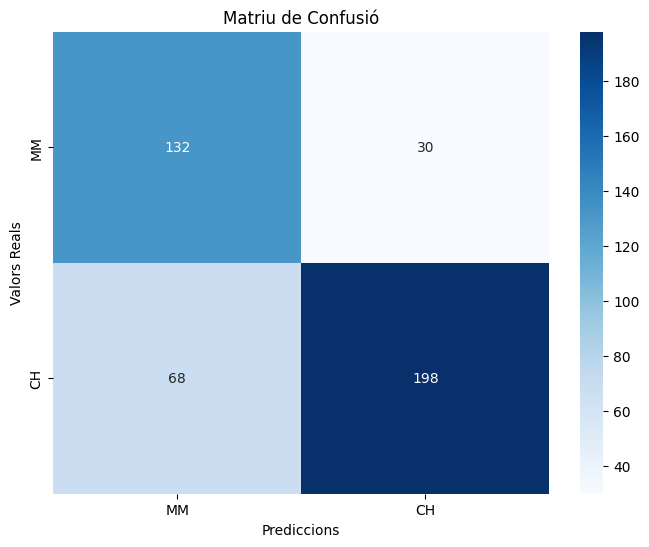


 
 Precisió en base de test: 77.10 %

 
 Informe de Classificació:


,precision,recall,f1-score,support
class,,,,
0,0.66,0.81,0.73,162.0
1,0.87,0.74,0.80,266.0


In [49]:
df_DataBase = pd.read_csv('OJ.csv')
df_DataBase['Store7'] = df_DataBase['Store7'].map({'Yes': 1, 'No': 0})
df_DataBase['Purchase'] = df_DataBase['Purchase'].map({'CH': 1, 'MM': 0})

X_train, X_temp, y_train, y_temp = train_test_split(df_DataBase[features], df_DataBase[target], test_size=0.4, random_state=42)

# Definir la graella de paràmetres
param_grid = {
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [ 5, 10, 20]
}

# Inicialitzar el classificador d'arbre de decisió
dt = DecisionTreeClassifier(random_state=42)

# Configurar GridSearchCV amb una validació creuada de 5 plecs
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='accuracy')

# Ajustar la cerca de graella als dades
grid_search.fit(X_train, y_train)

# Millors paràmetres
print("Millors paràmetres:", grid_search.best_params_)

# Millor puntuació de validació creuada
print(f"\n \n Millor precisió de validació creuada: {grid_search.best_score_*100:2.2f} %")

# Utilitzar el millor model per fer prediccions en el conjunt temporal per a la validació
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_temp)

# Matriu de confusió
conf_matrix = confusion_matrix(y_temp, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['MM', 'CH'], yticklabels=['MM', 'CH'])
plt.xlabel('Prediccions')
plt.ylabel('Valors Reals')
plt.title('Matriu de Confusió')
plt.show()

# Calcular la precisió en el conjunt temporal
accuracy = accuracy_score(y_temp, y_pred)
print(f'\n \n Precisió en base de test: {accuracy*100:2.2f} %')


report = classification_report(y_temp, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Optionally, if you want to reset the index to make 'precision', 'recall', etc., as columns:
df_report = df_report.reset_index()
df_report = df_report.rename(columns={'index': 'class'})
print('\n \n Informe de Classificació:')
df_report.set_index('class', inplace = True)

df_report.iloc[:2].round(2)

## <font color="red"><b>Exercici 17</b></font>
1. Per aclarir idees, expliqui el que fa el codi anterior en un parell de paràgrafs.

Començem llegint el dataset i mapejem els strings a valors numérics, després dividim el dataset entre train i tem i definim els paràmetres que volem. Inicialialitzem gridSearchCV per començar la validació creuada de 5 plecs. Dins de la graella, el que fem es una cerca per trobar quins son els paràmetres que ens apropen més a un arbre de decisió perfecte a base d'entrenar i comprobar 5 cops amb cadascún dels possibles paràmetres i validar amb el conjunt de validació que hem reservat per cadasqun dels cops. Una vegada ja tenim els paràmetres óptims, entrenem el model i el comprovem amb els valors de test que haviem reservat.

2. Per què les precisions del grid search i la de test són diferents?

Perquè es testejen amb conjunts diferents.

3. Qué pot dir sobre el Informae de Classificació després de fer la cerca exhaustiva?

Hem obtingut millors resultats de precissió, especialment en el cas 1, mentre que el recall del cas 1 empitjora una mica però millora molt pel cas 0. ELs f1-scores milloren per tots dos casos, a part, el support és molt més gran perquè ho hem comprobat amb cadascun dels folds.

4. Qué pot dir de la nova matriu de confusió en termes de falsos positius i falsos negatius.

Obtenim més falsos negatius però en percentatge molts millors estadístiques. Falsos negatius, obtenim menys falsos negatius directament.

## 4.6  Abre de decisió estimat amb validació creuada

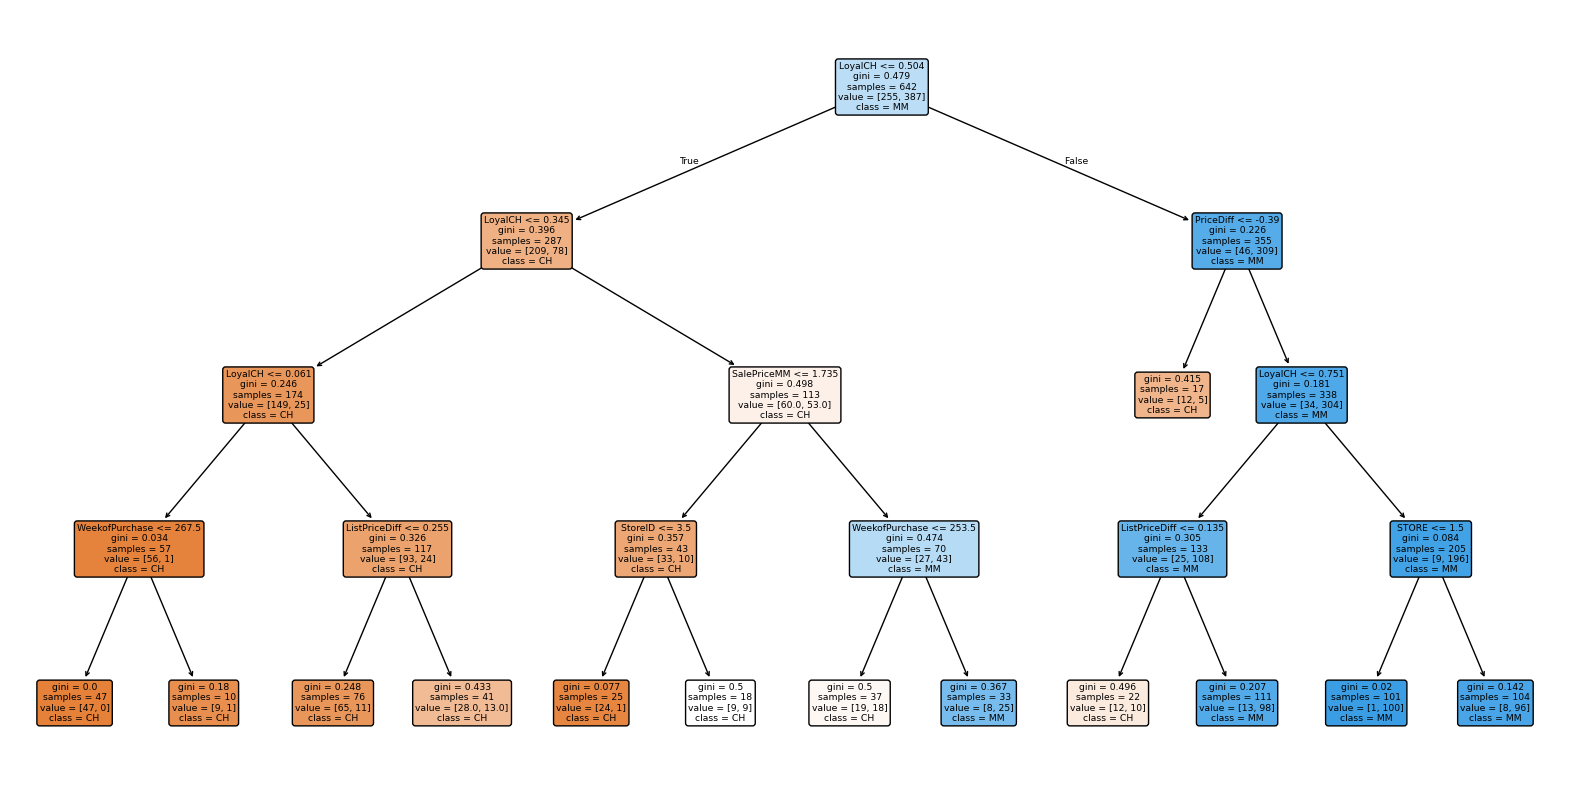

In [45]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(best_model, filled=True, rounded=True, feature_names=features,  class_names=['CH', 'MM'])
plt.show()

## <font color="red"><b>Exercici 18</b></font>
1. Interpreti l'arbre anterior. Hi ha alguna variable que sembli més important que d'altres? Hi ha alguna correlació entre les variables de decisió i el tipus de marca (CH, MM)? Pot proporcionar una jerarquia d'importància de les variables?

A les primeres branques de l'abre sembla que li donem més importancia a acotar la varible LoyalCH, a partir de cert punt que l'acabem de acotar passem amb les variables WeekofPurchase, ListPriceDiff, STORE, StorelD i gini. 

Si hi ha dues variables que estan sempre juntes, significa que estan correlades entre elles amb el resultat, ho podem apreciar amn LoyalCH => 0.061 i ListPriceDiff <= que a l'altra banda del arbre apareix com LoyalCH <= 0.751 i ListPriceDiff >= 0.0135.

Per la jerarquia, suposem que les variables de decisió que es comparen més a dalt del arbre són més importants/representativas que no les que es troben més a baix. 

## <font color="Blue"><b>Informe Final i Recomanacions</b></font>
1. Informe on es relaciona la informació obtinguda amb l'estudi fet amb l'EDA amb els resultats obtinguts pel mètode de machine learning.

2. Recomanacions per millorar el sistema i implementar-lo.

L'objectiu és analitzar una base de dades sobre compres de suc de taronja de dues marques, on a través de les diferents variables analitzar les decisions dels consumidors i intentar predir quina marca compraràn. 

Començem amb l'EDA d'on veiem que tenim 4 variables que clarament no es corresponen amb distribucions normals que son Purchase, StoreID, Store7 i STORE. També veiem que hi ha variables que tenen molts outliers, sobretot els relacionats amb els descomptes. També veiem com son aquestes variables així com LoyalCH les que ens permeten predir millor quina marca de suc compraran. Veiem que en general, els consumidors compren una mica més la marca 1. Una altra cosa que podem veure és que els descomptes de la marca 1 també son més efectius. 

Entrenem un model de decision tree i obtenim uns resultats no especialment bons, sobretot pel cas de la marca 0. Després d'utilitzar el métode de validació creuada a través de GridSearchCV, obtenim un arbre amb profunditat màxima = 4, mínim de mostres per fulla = 10 i mínim de mostres per node = 2. I amb aquests valors obtenim una precisió una mica millor, especialment per al cas de la marca 1. Del arbre resultant, podem veure que les variables més importants són LoyalCH, STORE, StorePriceDIff i StoreID com ja haviem vist a l'EDA i tmbé WeekofPurchase i gini.